# 기지국 그룹별 학습 실험

**가설**: 테스트 기지국과 유사한 특성을 가진 기지국만으로 학습하면 성능이 향상될 수 있다.

| 학습 데이터 | 예측 대상 |
|------------|----------|
| C, D | BaseStationB |
| H, I | BaseStationJ |

**비교 방식**
- 기존 방식: C+D+H+I 전체로 학습 → B, J 모두 예측
- 그룹별 방식: C+D로 B 예측, H+I로 J 예측
- 동일 전처리 파이프라인 적용, VotingRegressor(XGB+LGBM) 사용

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 1. 공통 전처리 함수

In [2]:
def categorize_hour(hour):
    if 0 <= hour < 7:
        return 'bedtime'
    elif 7 <= hour < 17:
        return 'day'
    else:
        return 'evening'

lag_var_list = ['nummsg3', 'erabaddatt', 'rlculbyte', 'bler_dl', 'attpaging', 'dltransmittedmcsavg']

def create_lag(df, var_list, num_lag=1):
    df['hour'] = df.index.hour
    for lag in range(num_lag):
        for var in var_list:
            df[f'{var}_lag{lag+1}'] = df.groupby('ru_id')[var].shift(1)
            df[f'{var}_lag{lag+1}'] = df.groupby(['ru_id', 'hour'])[f'{var}_lag{lag+1}'].transform(lambda x: x.fillna(x.mean()))
    df.drop('hour', axis=1, inplace=True)
    return df

drop_cols = [
    'rachpreamblea', 'time_of_day_day', 'endcaddsucc', 'erabaddsucc',
    'endcmodbymenbsucc', 'connestabsucc', 'handoversucc',
    'endcmodbysgnbsucc', 'reestabsucc'
]

ohe_cols = ['time_of_day_bedtime', 'time_of_day_evening']

def preprocess_train(raw_df, station_list):
    """Train 데이터 전처리 (결측처리 → 기지국필터 → FE → 피처제거)"""
    df = raw_df.copy()
    
    # 결측 처리
    df['time'] = pd.to_datetime(df['datetime']).dt.time
    df = df.sort_values(by=['time', 'ru_id'])
    grouped_means = df.drop('datetime', axis=1).groupby(['time', 'ru_id']).transform('mean')
    df[df.columns.difference(['datetime'])] = df[df.columns.difference(['datetime'])].fillna(grouped_means)
    df = df.sort_values(by=['datetime', 'ru_id'])
    df.drop('time', axis=1, inplace=True)
    
    # 기지국 필터
    df = df[df['ru_id'].isin(station_list)].copy()
    
    # 타겟 재배치
    target = df.pop('uenomax')
    df.insert(0, target.name, target)
    
    # datetime 처리
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['time_of_day'] = df['hour'].apply(categorize_hour)
    df.set_index('datetime', inplace=True)
    df.drop('hour', axis=1, inplace=True)
    
    # OHE + Lag + Drop
    df = pd.get_dummies(df, columns=['time_of_day'])
    df = create_lag(df, lag_var_list, num_lag=1)
    df.drop(drop_cols, axis=1, inplace=True)
    
    return df

def preprocess_test(test_df, station_name):
    """Test 데이터 전처리 (단일 기지국)"""
    df = test_df[test_df['ru_id'] == station_name].copy()
    df.drop(['Unnamed: 0'], axis=1, inplace=True, errors='ignore')
    
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['time_of_day'] = df['hour'].apply(categorize_hour)
    df.set_index('datetime', inplace=True)
    df.drop('hour', axis=1, inplace=True)
    
    df = pd.get_dummies(df, columns=['time_of_day'])
    df = create_lag(df, lag_var_list, num_lag=1)
    df.drop(drop_cols, axis=1, inplace=True)
    
    return df

def split_and_scale(df):
    """8:1:1 분할 + StandardScaler"""
    X = df.drop(['uenomax', 'ru_id'], axis=1)
    y = df['uenomax']
    
    train_size = int(0.8 * len(X))
    val_size = int(0.1 * len(X))
    
    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
    X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]
    
    feature_cols = [c for c in X_train.columns if c not in ohe_cols]
    scaler = StandardScaler()
    scaler.fit(X_train[feature_cols])
    
    def scale(split):
        scaled = pd.DataFrame(scaler.transform(split[feature_cols]), columns=feature_cols)
        ohe_reset = split[ohe_cols].reset_index(drop=True)
        return pd.concat([ohe_reset, scaled], axis=1)
    
    return scale(X_train), scale(X_val), scale(X_test), y_train, y_val, y_test, scaler

def scale_test_data(test_df, scaler):
    """Test 데이터에 학습된 scaler 적용"""
    feature_cols = [c for c in test_df.columns if c not in ohe_cols + ['ru_id']]
    X = test_df.drop(['ru_id'], axis=1, errors='ignore')
    
    scaled = pd.DataFrame(scaler.transform(X[feature_cols]), columns=feature_cols)
    ohe_reset = X[ohe_cols].reset_index(drop=True)
    return pd.concat([ohe_reset, scaled], axis=1)

print("전처리 함수 정의 완료")

전처리 함수 정의 완료


## 2. 데이터 로드 및 전처리

In [3]:
# ── 원본 데이터 로드 ──
Q1_train_raw = pd.read_csv('../Q1_data/Q1_train.csv')
Q1_test_raw = pd.read_csv('../Q1_data/Q1_test.csv')

# ── 기존 방식: C+D+H+I 전체 ──
df_all = preprocess_train(Q1_train_raw, ['BaseStationC', 'BaseStationD', 'BaseStationH', 'BaseStationI'])
sX_train_all, sX_val_all, sX_test_all, y_train_all, y_val_all, y_test_all, scaler_all = split_and_scale(df_all)
print(f"[기존] C+D+H+I 전체 → Train: {sX_train_all.shape}")

# ── 그룹 1: C+D → B 예측용 ──
df_cd = preprocess_train(Q1_train_raw, ['BaseStationC', 'BaseStationD'])
sX_train_cd, sX_val_cd, sX_test_cd, y_train_cd, y_val_cd, y_test_cd, scaler_cd = split_and_scale(df_cd)
print(f"[그룹1] C+D → Train: {sX_train_cd.shape}")

# ── 그룹 2: H+I → J 예측용 ──
df_hi = preprocess_train(Q1_train_raw, ['BaseStationH', 'BaseStationI'])
sX_train_hi, sX_val_hi, sX_test_hi, y_train_hi, y_val_hi, y_test_hi, scaler_hi = split_and_scale(df_hi)
print(f"[그룹2] H+I → Train: {sX_train_hi.shape}")

[기존] C+D+H+I 전체 → Train: (54979, 36)
[그룹1] C+D → Train: (27489, 36)
[그룹2] H+I → Train: (27489, 36)


## 3. 모델 학습 (Voting: XGB + LGBM)

In [4]:
def make_voting():
    return VotingRegressor(estimators=[
        ('XGBoost', XGBRegressor(n_estimators=200, n_jobs=-1, random_state=48)),
        ('LightGBM', LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=48, verbose=-1)),
    ])

def train_and_eval(name, model, sX_train, sX_val, sX_test, y_train, y_val, y_test):
    start = time.time()
    model.fit(sX_train, y_train)
    train_time = time.time() - start
    
    rows = []
    for split_name, X_s, y_s in [('Val', sX_val, y_val), ('Test', sX_test, y_test)]:
        y_pred = np.round(model.predict(X_s)).astype(int)
        rows.append({
            'Model': name,
            'Split': split_name,
            'MAE': mean_absolute_error(y_s, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_s, y_pred)),
            'R2': r2_score(y_s, y_pred),
            'Train Time (s)': round(train_time, 2),
        })
    return model, rows

# ── 기존 방식: C+D+H+I 전체 모델 ──
model_all, results_all = train_and_eval(
    '기존: C+D+H+I → All', make_voting(),
    sX_train_all, sX_val_all, sX_test_all, y_train_all, y_val_all, y_test_all
)
print("기존 모델 학습 완료")

# ── 그룹별 방식 ──
# 그룹1: C+D 모델
model_cd, results_cd = train_and_eval(
    '그룹별: C+D → B', make_voting(),
    sX_train_cd, sX_val_cd, sX_test_cd, y_train_cd, y_val_cd, y_test_cd
)
print("그룹1 (C+D) 모델 학습 완료")

# 그룹2: H+I 모델
model_hi, results_hi = train_and_eval(
    '그룹별: H+I → J', make_voting(),
    sX_train_hi, sX_val_hi, sX_test_hi, y_train_hi, y_val_hi, y_test_hi
)
print("그룹2 (H+I) 모델 학습 완료")

기존 모델 학습 완료
그룹1 (C+D) 모델 학습 완료
그룹2 (H+I) 모델 학습 완료


## 4. Train 내부 평가 비교 (Val / Test Split)

In [5]:
# ── Train 내부 성능 비교 표 ──
all_results = results_all + results_cd + results_hi
results_df = pd.DataFrame(all_results)

val_df = results_df[results_df['Split'] == 'Val'].drop('Split', axis=1).set_index('Model')
test_df = results_df[results_df['Split'] == 'Test'].drop('Split', axis=1).set_index('Model')

internal_comparison = pd.DataFrame({
    'Val MAE': val_df['MAE'],
    'Test MAE': test_df['MAE'],
    'Val RMSE': val_df['RMSE'],
    'Test RMSE': test_df['RMSE'],
    'Val R²': val_df['R2'],
    'Test R²': test_df['R2'],
})

print("=" * 80)
print("Train 내부 평가 (8:1:1 Split 기준)")
print("=" * 80)
internal_comparison.round(4)

Train 내부 평가 (8:1:1 Split 기준)


,Val MAE,Test MAE,Val RMSE,Test RMSE,Val R²,Test R²
Model,,,,,,
기존: C+D+H+I → All,0.4719,0.4881,0.7558,0.7711,0.7802,0.7782
그룹별: C+D → B,0.5640,0.5784,0.8533,0.8556,0.6928,0.7097
그룹별: H+I → J,0.3917,0.4027,0.6638,0.6784,0.6313,0.6344


## 5. Q1_test.csv 추론 비교 (기존 vs 그룹별)

100% Train으로 재학습 후 실제 테스트 데이터에 대해 예측 결과를 비교합니다.

In [6]:
# ── 100% Train 재학습 ──

# 기존 방식: C+D+H+I 전체
X_full_all = df_all.drop(['uenomax', 'ru_id'], axis=1)
y_full_all = df_all['uenomax']
feature_cols = [c for c in X_full_all.columns if c not in ohe_cols]

scaler_full_all = StandardScaler()
scaler_full_all.fit(X_full_all[feature_cols])
sX_full_all = pd.concat([
    X_full_all[ohe_cols].reset_index(drop=True),
    pd.DataFrame(scaler_full_all.transform(X_full_all[feature_cols]), columns=feature_cols)
], axis=1)

model_full_all = make_voting()
model_full_all.fit(sX_full_all, y_full_all)
print("기존 모델 (100% Train) 학습 완료")

# 그룹1: C+D
X_full_cd = df_cd.drop(['uenomax', 'ru_id'], axis=1)
y_full_cd = df_cd['uenomax']

scaler_full_cd = StandardScaler()
scaler_full_cd.fit(X_full_cd[feature_cols])
sX_full_cd = pd.concat([
    X_full_cd[ohe_cols].reset_index(drop=True),
    pd.DataFrame(scaler_full_cd.transform(X_full_cd[feature_cols]), columns=feature_cols)
], axis=1)

model_full_cd = make_voting()
model_full_cd.fit(sX_full_cd, y_full_cd)
print("그룹1 C+D 모델 (100% Train) 학습 완료")

# 그룹2: H+I
X_full_hi = df_hi.drop(['uenomax', 'ru_id'], axis=1)
y_full_hi = df_hi['uenomax']

scaler_full_hi = StandardScaler()
scaler_full_hi.fit(X_full_hi[feature_cols])
sX_full_hi = pd.concat([
    X_full_hi[ohe_cols].reset_index(drop=True),
    pd.DataFrame(scaler_full_hi.transform(X_full_hi[feature_cols]), columns=feature_cols)
], axis=1)

model_full_hi = make_voting()
model_full_hi.fit(sX_full_hi, y_full_hi)
print("그룹2 H+I 모델 (100% Train) 학습 완료")

기존 모델 (100% Train) 학습 완료
그룹1 C+D 모델 (100% Train) 학습 완료
그룹2 H+I 모델 (100% Train) 학습 완료


In [7]:
# ── Q1_test 전처리 ──
test_B = preprocess_test(Q1_test_raw, 'BaseStationB')
test_J = preprocess_test(Q1_test_raw, 'BaseStationJ')

# ── 기존 방식: 전체 모델로 B, J 예측 ──
stest_B_all = scale_test_data(test_B, scaler_full_all)
stest_J_all = scale_test_data(test_J, scaler_full_all)
pred_B_baseline = np.round(model_full_all.predict(stest_B_all)).astype(int)
pred_J_baseline = np.round(model_full_all.predict(stest_J_all)).astype(int)

# ── 그룹별 방식: C+D→B, H+I→J ──
stest_B_cd = scale_test_data(test_B, scaler_full_cd)
stest_J_hi = scale_test_data(test_J, scaler_full_hi)
pred_B_group = np.round(model_full_cd.predict(stest_B_cd)).astype(int)
pred_J_group = np.round(model_full_hi.predict(stest_J_hi)).astype(int)

# ── 예측 결과 미리보기 ──
datetime_col = Q1_test_raw['datetime'].drop_duplicates().reset_index(drop=True)

submission_baseline = pd.DataFrame({
    'datetime': datetime_col,
    'BaseStationB': pred_B_baseline,
    'BaseStationJ': pred_J_baseline,
})

submission_group = pd.DataFrame({
    'datetime': datetime_col,
    'BaseStationB': pred_B_group,
    'BaseStationJ': pred_J_group,
})

print("기존 방식 예측:")
display(submission_baseline.head(6))
print("\n그룹별 방식 예측:")
display(submission_group.head(6))

기존 방식 예측:


,datetime,BaseStationB,BaseStationJ
0,2023-05-19 00:00:00,1,1
1,2023-05-19 00:05:00,2,2
2,2023-05-19 00:10:00,2,1
3,2023-05-19 00:15:00,2,1
4,2023-05-19 00:20:00,2,2
5,2023-05-19 00:25:00,1,1



그룹별 방식 예측:


,datetime,BaseStationB,BaseStationJ
0,2023-05-19 00:00:00,1,1
1,2023-05-19 00:05:00,2,2
2,2023-05-19 00:10:00,2,1
3,2023-05-19 00:15:00,2,1
4,2023-05-19 00:20:00,2,2
5,2023-05-19 00:25:00,2,1


## 6. 예측 분포 비교

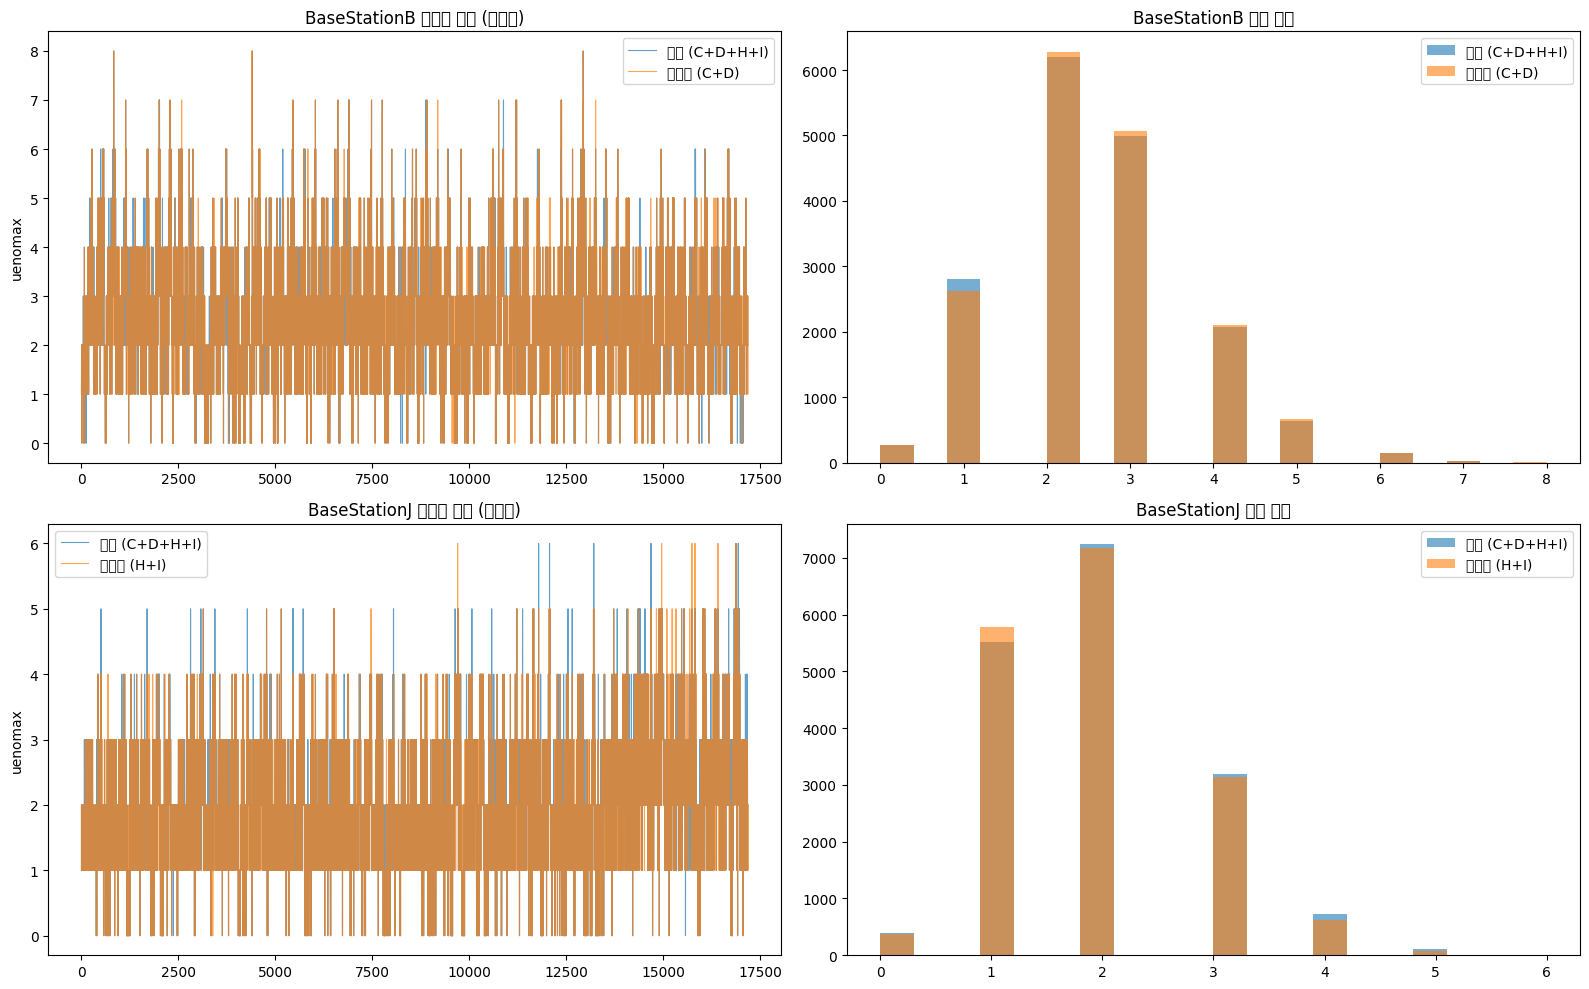


BaseStationB 예측 차이 (그룹별 - 기존): mean=0.021, std=0.385, 동일 비율=85.2%
BaseStationJ 예측 차이 (그룹별 - 기존): mean=-0.038, std=0.376, 동일 비율=85.8%


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# BaseStationB 예측 비교
axes[0, 0].plot(pred_B_baseline, alpha=0.7, label='기존 (C+D+H+I)', linewidth=0.8)
axes[0, 0].plot(pred_B_group, alpha=0.7, label='그룹별 (C+D)', linewidth=0.8)
axes[0, 0].set_title('BaseStationB 예측값 비교 (시계열)')
axes[0, 0].legend()
axes[0, 0].set_ylabel('uenomax')

axes[0, 1].hist(pred_B_baseline, bins=20, alpha=0.6, label='기존 (C+D+H+I)')
axes[0, 1].hist(pred_B_group, bins=20, alpha=0.6, label='그룹별 (C+D)')
axes[0, 1].set_title('BaseStationB 예측 분포')
axes[0, 1].legend()

# BaseStationJ 예측 비교
axes[1, 0].plot(pred_J_baseline, alpha=0.7, label='기존 (C+D+H+I)', linewidth=0.8)
axes[1, 0].plot(pred_J_group, alpha=0.7, label='그룹별 (H+I)', linewidth=0.8)
axes[1, 0].set_title('BaseStationJ 예측값 비교 (시계열)')
axes[1, 0].legend()
axes[1, 0].set_ylabel('uenomax')

axes[1, 1].hist(pred_J_baseline, bins=20, alpha=0.6, label='기존 (C+D+H+I)')
axes[1, 1].hist(pred_J_group, bins=20, alpha=0.6, label='그룹별 (H+I)')
axes[1, 1].set_title('BaseStationJ 예측 분포')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../기지국그룹별_예측비교.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 차이 요약 통계 ──
diff_B = pred_B_group - pred_B_baseline
diff_J = pred_J_group - pred_J_baseline

print(f"\nBaseStationB 예측 차이 (그룹별 - 기존): mean={diff_B.mean():.3f}, std={diff_B.std():.3f}, 동일 비율={np.mean(diff_B == 0)*100:.1f}%")
print(f"BaseStationJ 예측 차이 (그룹별 - 기존): mean={diff_J.mean():.3f}, std={diff_J.std():.3f}, 동일 비율={np.mean(diff_J == 0)*100:.1f}%")